In [24]:
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
import numpy as np

In [8]:
digits_mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) =  digits_mnist.load_data(path="mnist.npz")


In [9]:
# normalization
train_images = train_images / 255.0
test_images  = test_images / 255.0

In [13]:
# after normalization: 0<= min <= max <= 1
print(train_images.min())
print(train_images.max())

0.0
1.0


In [29]:
def model_plot(history):
  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.plot(history.history['accuracy'])
  plt.plot(history.history['val_accuracy'])
  plt.legend(['accuracy', 'val_accuracy'])

  plt.subplot(1, 2, 2)
  plt.plot(history.history['loss'])
  plt.plot(history.history['val_loss'])
  plt.legend(['loss', 'val_loss'])

  plt.tight_layout()
  plt.show()

In [28]:
model = keras.Sequential([
  keras.layers.Conv2D(32, (3,3), padding= 'same', input_shape = (28, 28, 1)),
  keras.layers.Flatten(),
  keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
  optimizer= "adam",
  loss = 'sparse_categorical_crossentropy',
  metrics= ['accuracy']
)

model.summary()

h1 = model.fit(
  train_images, train_labels,
  batch_size= 128, epochs= 10,
  validation_data=(test_images, test_labels)
)

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │       250,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,210 (981.29 KB)

 Trainable params: 251,210 (981.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8974 - loss: 0.3590 - val_accuracy: 0.9100 - val_loss: 0.3102
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9178 - loss: 0.2912 - val_accuracy: 0.9213 - val_loss: 0.2787
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9222 - loss: 0.2781 - val_accuracy: 0.9205 - val_loss: 0.2787
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9243 - loss: 0.2707 - val_accuracy: 0.9210 - val_loss: 0.2817
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9249 - loss: 0.2661 - val_accuracy: 0.9216 - val_loss: 0.2843
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9266 - loss: 0.2623 - val_accuracy: 0.9208 - val_loss: 0.2814
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9275 - loss: 0.2592 - val_accuracy: 0.9216 - val_loss: 0.2770
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9275 - loss: 0.2563 - val_accu

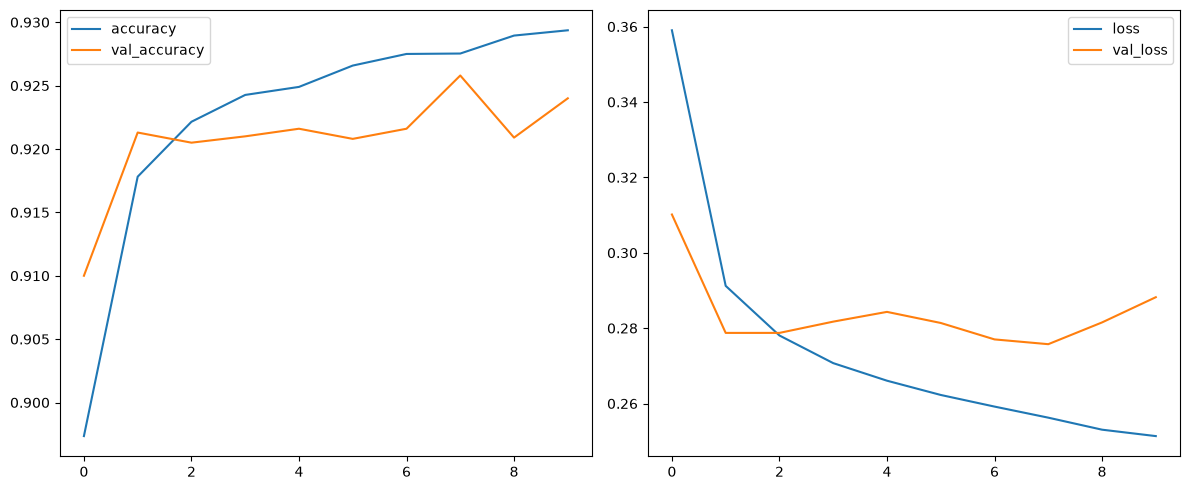

In [30]:
model_plot(h1)

In [31]:
model = keras.Sequential([
  keras.layers.Conv2D(32, (3,3), padding= 'same', input_shape = (28, 28, 1)),
  keras.layers.BatchNormalization(),
  keras.layers.Flatten(),
  keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
  optimizer= "adam",
  loss = 'sparse_categorical_crossentropy',
  metrics= ['accuracy']
)

model.summary()

h2= model.fit(
  train_images, train_labels,
  batch_size= 128, epochs= 10,
  validation_data=(test_images, test_labels)
)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │       250,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,338 (981.79 KB)

 Trainable params: 251,274 (981.54 KB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.8736 - loss: 0.5390 - val_accuracy: 0.9042 - val_loss: 0.4170
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9069 - loss: 0.3340 - val_accuracy: 0.9043 - val_loss: 0.3311
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9151 - loss: 0.2969 - val_accuracy: 0.8971 - val_loss: 0.3650
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9188 - loss: 0.2833 - val_accuracy: 0.9127 - val_loss: 0.3082
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.9218 - loss: 0.2774 - val_accuracy: 0.9147 - val_loss: 0.3096
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9222 - loss: 0.2716 - val_accuracy: 0.9083 - val_loss: 0.3433
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9245 - loss: 0.2669 - val_accuracy: 0.9174 - val_loss: 0.2990
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9255 - loss: 0.2641 - 

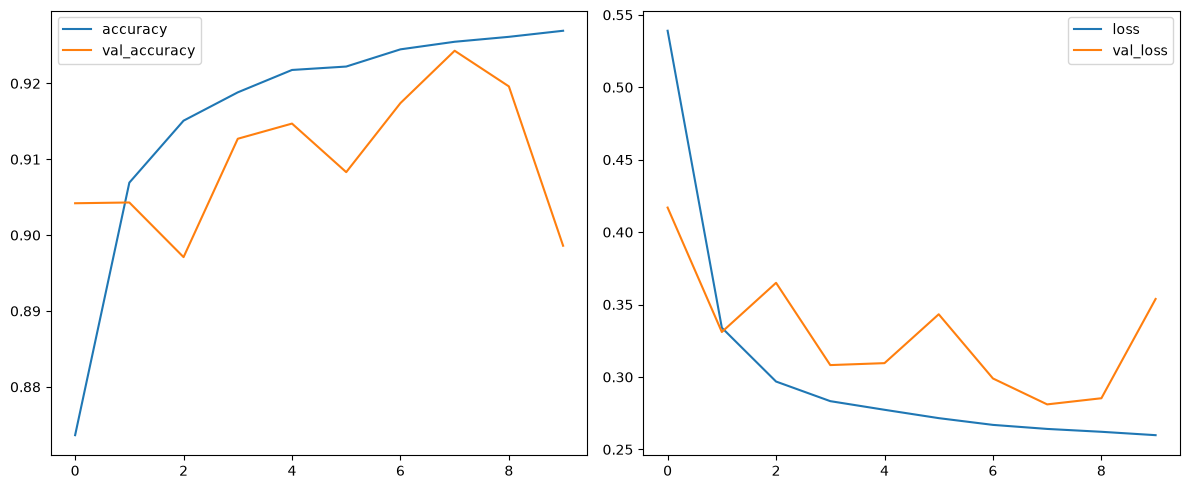

In [32]:
model_plot(h2)

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,130 (12.26 MB)

 Trainable params: 3,213,066 (12.26 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - accuracy: 0.9093 - loss: 0.3667 - val_accuracy: 0.9458 - val_loss: 0.2193
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.9564 - loss: 0.1481 - val_accuracy: 0.9587 - val_loss: 0.1412
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9686 - loss: 0.1022 - val_accuracy: 0.9586 - val_loss: 0.1447
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9754 - loss: 0.0785 - val_accuracy: 0.9606 - val_loss: 0.1429
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 32s 67ms/step - accuracy: 0.9789 - loss: 0.0654 - val_accuracy: 0.9585 - val_loss: 0.1492
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 67ms/step - accuracy: 0.9807 - loss: 0.0588 - val_accuracy: 0.9555 - val_loss: 0.1657
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.9833 - loss: 0.0489 - val_accuracy: 0.9442 - val_loss: 0.2458
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.9863 - loss: 0.0423 - 

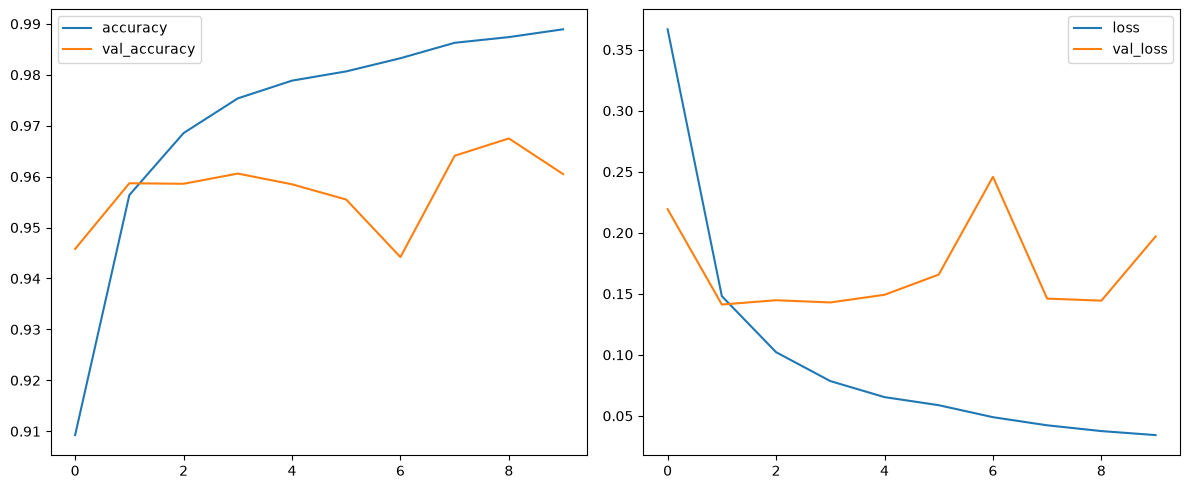

In [34]:
model = keras.Sequential([
  keras.layers.Conv2D(32, (3,3), padding= 'same', input_shape = (28, 28, 1)),
  keras.layers.BatchNormalization(),
  keras.layers.Flatten(),
  keras.layers.Dense(128, activation = "relu"),
  keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
  optimizer= "adam",
  loss = 'sparse_categorical_crossentropy',
  metrics= ['accuracy']
)

model.summary()

h3= model.fit(
  train_images, train_labels,
  batch_size= 128, epochs= 10,
  validation_data=(test_images, test_labels)
)
model_plot(h3)

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,130 (12.26 MB)

 Trainable params: 3,213,066 (12.26 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.8845 - loss: 0.4165 - val_accuracy: 0.9479 - val_loss: 0.1979
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9344 - loss: 0.2231 - val_accuracy: 0.9555 - val_loss: 0.1653
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9474 - loss: 0.1710 - val_accuracy: 0.9596 - val_loss: 0.1483
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.9566 - loss: 0.1400 - val_accuracy: 0.9640 - val_loss: 0.1353
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.9611 - loss: 0.1239 - val_accuracy: 0.9632 - val_loss: 0.1342
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.9652 - loss: 0.1111 - val_accuracy: 0.9684 - val_loss: 0.1212
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 30s 65ms/step - accuracy: 0.9677 - loss: 0.0983 - val_accuracy: 0.9701 - val_loss: 0.1222
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 59ms/step - accuracy: 0.9699 - loss: 0.0923 - 

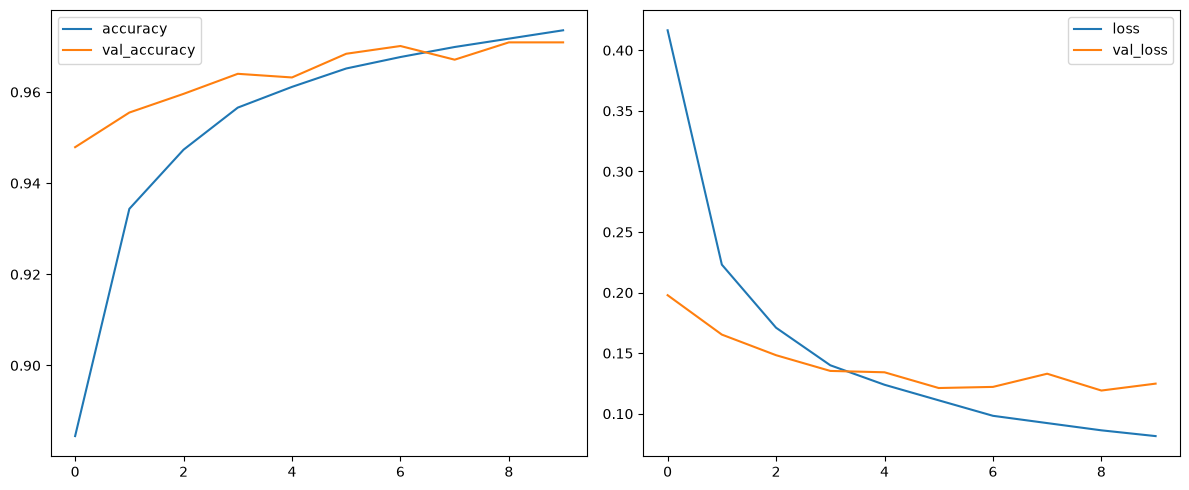

In [36]:
model = keras.Sequential([
  keras.layers.Conv2D(32, (3,3), padding= 'same', input_shape = (28, 28, 1)),
  keras.layers.BatchNormalization(),
  keras.layers.Flatten(),
  keras.layers.Dense(128, activation = "relu"),
  keras.layers.Dropout(0.2),
  keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
  optimizer= "adam",
  loss = 'sparse_categorical_crossentropy',
  metrics= ['accuracy']
)

model.summary()

h4= model.fit(
  train_images, train_labels,
  batch_size= 128, epochs= 10,
  validation_data=(test_images, test_labels)
)
model_plot(h4)

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,130 (12.26 MB)

 Trainable params: 3,213,066 (12.26 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 64ms/step - accuracy: 0.8860 - loss: 0.4330 - val_accuracy: 0.9455 - val_loss: 0.1995
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9356 - loss: 0.2200 - val_accuracy: 0.9539 - val_loss: 0.1731
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9494 - loss: 0.1672 - val_accuracy: 0.9477 - val_loss: 0.2206
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.9591 - loss: 0.1332 - val_accuracy: 0.9662 - val_loss: 0.1425
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.9628 - loss: 0.1181 - val_accuracy: 0.9562 - val_loss: 0.1880
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 28s 61ms/step - accuracy: 0.9651 - loss: 0.1069 - val_accuracy: 0.9668 - val_loss: 0.1186
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 61ms/step - accuracy: 0.9688 - loss: 0.0958 - val_accuracy: 0.9666 - val_loss: 0.1343
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.9716 - loss: 0.0864 - 

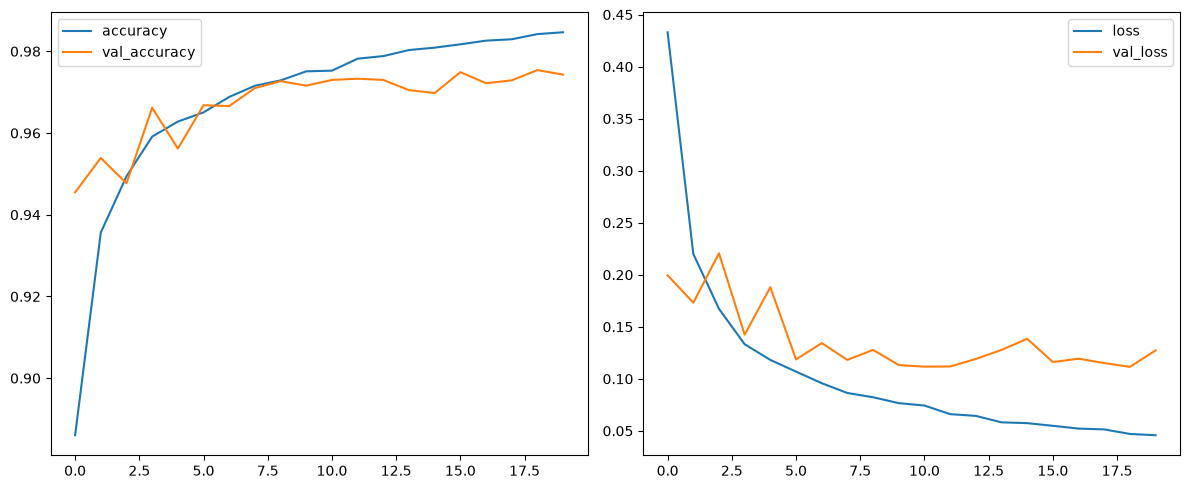

In [38]:
model = keras.Sequential([
  keras.layers.Conv2D(32, (3,3), padding= 'same', input_shape = (28, 28, 1)),
  keras.layers.BatchNormalization(),
  keras.layers.Flatten(),
  keras.layers.Dense(128, activation = "relu"),
  keras.layers.Dropout(0.2),
  keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
  optimizer= "adam",
  loss = 'sparse_categorical_crossentropy',
  metrics= ['accuracy']
)

model.summary()

h5= model.fit(
  train_images, train_labels,
  batch_size= 128, epochs= 20,
  validation_data=(test_images, test_labels)
)
model_plot(h5)

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,213,130 (12.26 MB)

 Trainable params: 3,213,066 (12.26 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 76ms/step - accuracy: 0.8964 - loss: 0.4064 - val_accuracy: 0.9655 - val_loss: 0.1748
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 69ms/step - accuracy: 0.9610 - loss: 0.1283 - val_accuracy: 0.9731 - val_loss: 0.0895
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.9703 - loss: 0.0946 - val_accuracy: 0.9768 - val_loss: 0.0696
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9748 - loss: 0.0781 - val_accuracy: 0.9479 - val_loss: 0.1688
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.9791 - loss: 0.0650 - val_accuracy: 0.9786 - val_loss: 0.0681
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9810 - loss: 0.0572 - val_accuracy: 0.9784 - val_loss: 0.0736
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 73ms/step - accuracy: 0.9834 - loss: 0.0498 - val_accuracy: 0.9787 - val_loss: 0.0684
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9851 - loss: 0.0446 - 

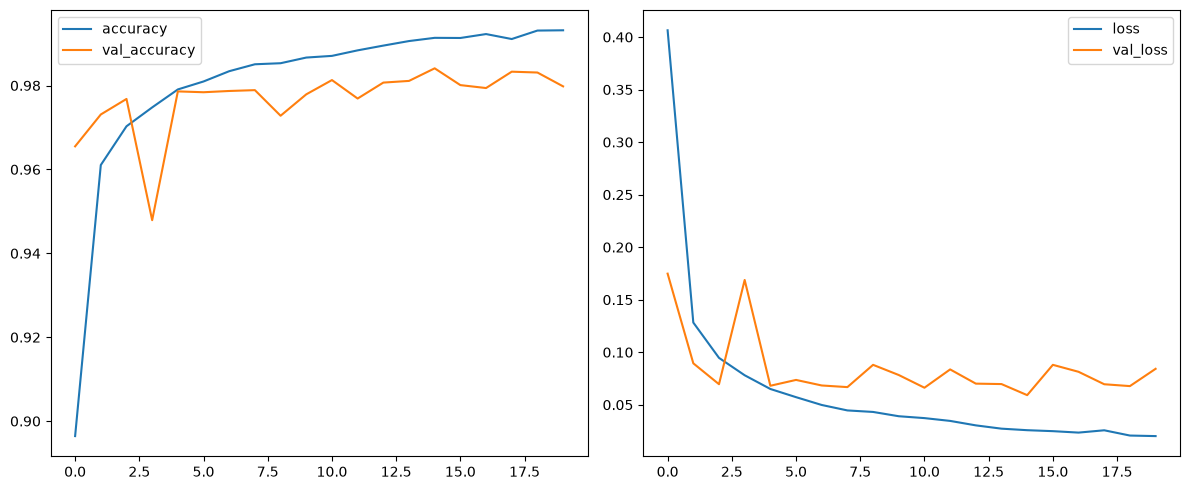

In [40]:
model = keras.Sequential([
  keras.layers.Conv2D(32, (3,3), padding= 'same', input_shape = (28, 28, 1)),
  keras.layers.BatchNormalization(),
  keras.layers.Activation(activation="relu"),
  keras.layers.Flatten(),
  keras.layers.Dense(128, activation = "relu"),
  keras.layers.Dropout(0.2),
  keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
  optimizer= "adam",
  loss = 'sparse_categorical_crossentropy',
  metrics= ['accuracy']
)

model.summary()

h6= model.fit(
  train_images, train_labels,
  batch_size= 128, epochs= 20,
  validation_data=(test_images, test_labels)
)
model_plot(h6)

/home/sothea/miniconda3/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 804,682 (3.07 MB)

 Trainable params: 804,618 (3.07 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.9154 - loss: 0.2818 - val_accuracy: 0.9296 - val_loss: 0.2396
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9679 - loss: 0.1066 - val_accuracy: 0.9772 - val_loss: 0.0662
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9761 - loss: 0.0782 - val_accuracy: 0.9819 - val_loss: 0.0579
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.9794 - loss: 0.0643 - val_accuracy: 0.9830 - val_loss: 0.0507
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9827 - loss: 0.0527 - val_accuracy: 0.9831 - val_loss: 0.0482
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 27s 57ms/step - accuracy: 0.9850 - loss: 0.0471 - val_accuracy: 0.9851 - val_loss: 0.0495
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9862 - loss: 0.0420 - val_accuracy: 0.9824 - val_loss: 0.0565
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9859 - loss: 0.0425 - 

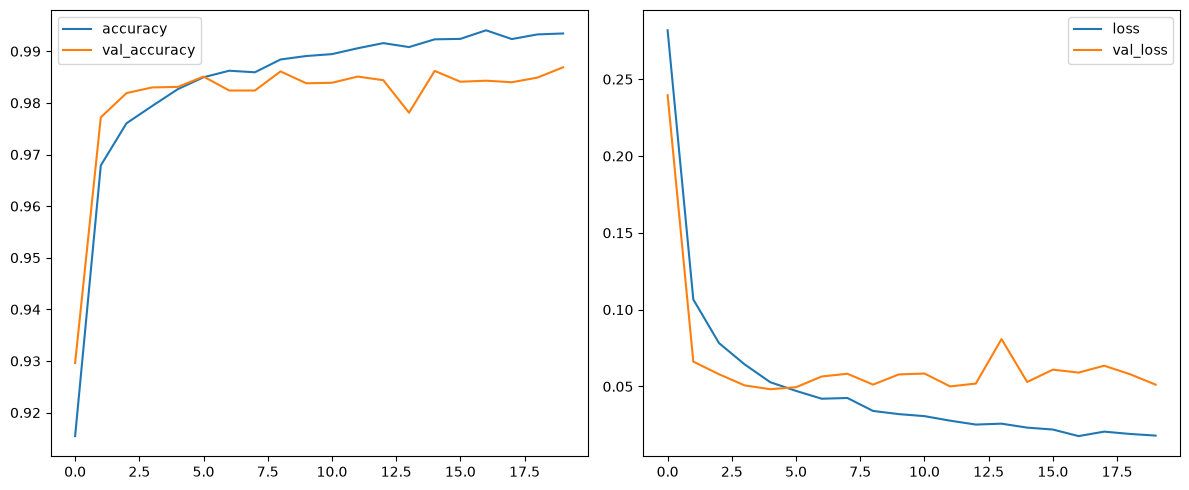

In [41]:
model = keras.Sequential([
  keras.layers.Conv2D(32, (3,3), padding= 'same', input_shape = (28, 28, 1)),
  keras.layers.BatchNormalization(),
  keras.layers.Activation(activation="relu"),
  keras.layers.MaxPool2D((2, 2)),
  keras.layers.Flatten(),
  keras.layers.Dense(128, activation = "relu"),
  keras.layers.Dropout(0.2),
  keras.layers.Dense(10, activation=tf.nn.softmax)
])
model.compile(
  optimizer= "adam",
  loss = 'sparse_categorical_crossentropy',
  metrics= ['accuracy']
)

model.summary()

h7 = model.fit(
  train_images, train_labels,
  batch_size= 128, epochs= 20,
  validation_data=(test_images, test_labels)
)
model_plot(h7)

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,770 (1.61 MB)

 Trainable params: 421,706 (1.61 MB)

 Non-trainable params: 64 (256.00 B)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9489 - loss: 0.1680 - val_accuracy: 0.9838 - val_loss: 0.0925
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.9846 - loss: 0.0494 - val_accuracy: 0.9900 - val_loss: 0.0307
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.9890 - loss: 0.0348 - val_accuracy: 0.9907 - val_loss: 0.0296
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.9911 - loss: 0.0271 - val_accuracy: 0.9908 - val_loss: 0.0310
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9930 - loss: 0.0213 - val_accuracy: 0.9894 - val_loss: 0.0343
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - accuracy: 0.9940 - loss: 0.0184 - val_accuracy: 0.9905 - val_loss: 0.0322
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.9948 - loss: 0.0156 - val_accuracy: 0.9932 - val_loss: 0.0259
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9949 - loss: 0.0148 - 

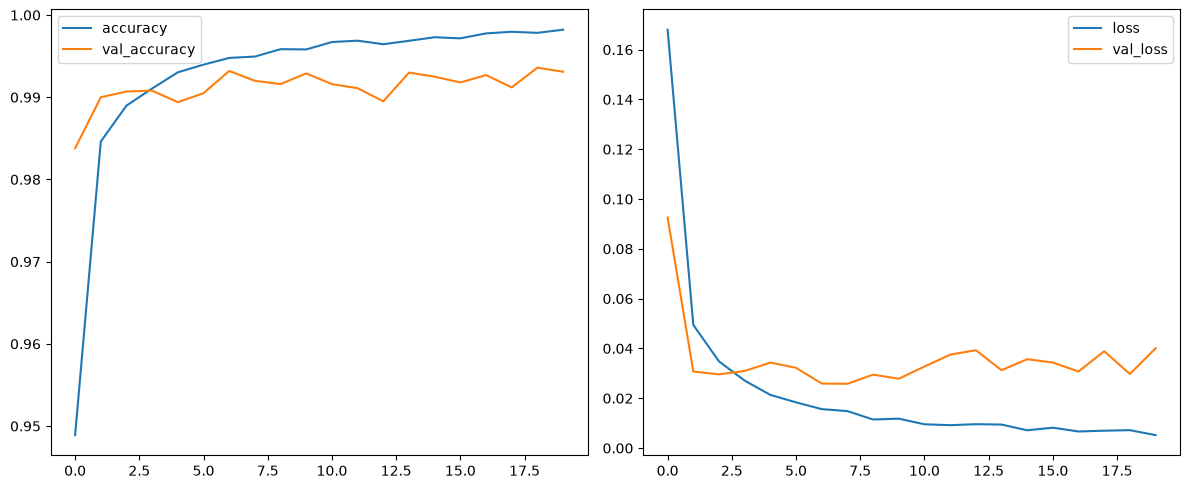

In [45]:
model = keras.Sequential([
  keras.layers.Conv2D(32, (3,3), padding= 'same', input_shape = (28, 28, 1)),
  keras.layers.BatchNormalization(),
  keras.layers.Activation(activation="relu"),
  keras.layers.MaxPool2D((2, 2)),
  keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),  # new layer
  keras.layers.MaxPooling2D((2,2)),
  keras.layers.Flatten(),
  keras.layers.Dense(128, activation = "relu"),
  keras.layers.Dropout(0.2),
  keras.layers.Dense(10, activation="softmax")
])
model.compile(
  optimizer= "adam",
  loss = 'sparse_categorical_crossentropy',
  metrics= ['accuracy']
)

model.summary()

h8 = model.fit(
  train_images, train_labels,
  batch_size= 128, epochs= 20,
  validation_data=(test_images, test_labels)
)
model_plot(h8)

In [46]:
model.save("mnist_model_1.keras")